In [1]:
import pandas as pd
import pickle
import os
import cv2
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

In [2]:
dir_path = '/home/firdavs/CholecT45'
video_name = 'VID01'
num_frames = 20

## 1. Visualize frames

In [3]:
data_dir = os.path.join(dir_path, 'data', video_name)

frame = cv2.imread(os.path.join(data_dir, '000000.png'))
height, width, _ = frame.shape
print(f"height: {height}, width: {width}")
fourcc = cv2.VideoWriter_fourcc(*'XVID')
fps = 1
video_path = os.path.join('../data/CholecT45-related/videos', video_name + '.avi')
os.makedirs(os.path.dirname(video_path), exist_ok=True)
video = cv2.VideoWriter(video_path, fourcc, fps, (width, height))

for frame_idx in range(num_frames):
    frame_path = os.path.join(data_dir, f'{frame_idx:06d}.png')
    video.write(cv2.imread(frame_path))
    
cv2.destroyAllWindows()
video.release()

height: 480, width: 854


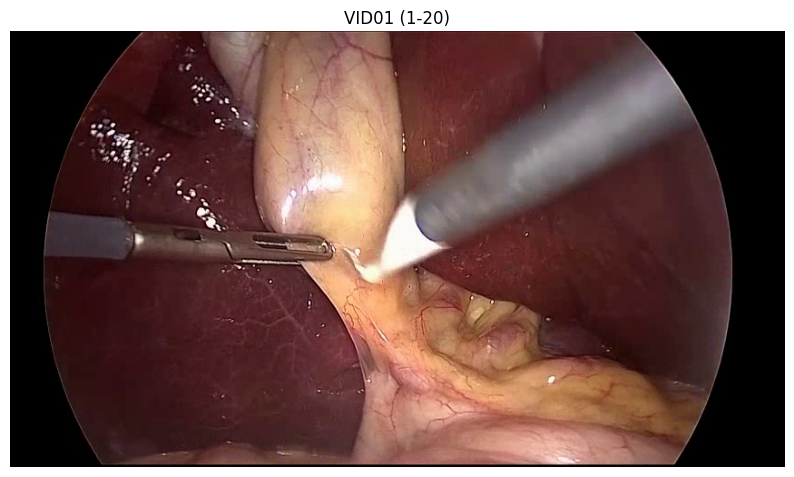

In [4]:
def display_video(video_path, delay=0.1, title=None):
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # Convert BGR to RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Display the frame
        plt.figure(figsize=(10, 8))
        plt.imshow(rgb_frame)
        if title:
            plt.title(title)
        plt.axis('off')
        display(plt.gcf())
        plt.close()
        
        time.sleep(delay)  # Pause between frames
        clear_output(wait=True)  # Clear previous frame
    
    cap.release()

display_video(video_path, title=f"{video_name} (1-{num_frames})")

## 2. Get all dict mappings

In [5]:
dict_dir = os.path.join(dir_path, 'dict')

# ID -> instrument, target, triplet, verb
files = ['instrument.txt', 'target.txt', 'triplet.txt', 'verb.txt']
dicts = {}
for file in files:
    file_path = os.path.join(dict_dir, file)
    with open(file_path, 'r') as f:
        data = f.readlines()
    dict_ = {}
    for line in data:
        split_list = line.strip().split(':')
        dict_[split_list[0]] = split_list[1]
    dicts[file] = dict_

In [6]:
# Triplet ID -> instrument ID, verb ID, target ID, instrument-verb ID, instrument-target ID
file_path = os.path.join(dict_dir, 'maps.txt')
with open(file_path, 'r') as f:
    data = f.readlines()
maps = {}
for line in data:
    split_list = line.strip().split(',')
    maps[split_list[0]] = split_list[1:]
dicts['maps'] = maps


In [7]:
import json
json.dump(dicts, open('../data/CholecT45-related/dicts.json', 'w'), indent=4)

## CholecT45 Finetune Dataset

In [8]:
import torch
from PIL import Image
import numpy as np

class CholecT45FinetuneDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, video_ids, sequence_length, stride, transform=None):
        self.data_dir = data_dir
        self.video_ids = video_ids
        self.sequence_length = sequence_length
        self.stride = stride
        self.transform = transform
        self.frame_indices = {}
        self.labels = {'inst': {}, 'verb': {}, 'target': {}}
        
        # Load frame indices and labels
        for vid in video_ids:
            # Load frame indices from triplet file
            annot_file = os.path.join(data_dir, 'triplet', f'{vid}.txt')
            with open(annot_file, 'r') as f:
                data = pd.read_csv(f, header=None)
            frame_indices = data[0].tolist()
            self.frame_indices[vid] = frame_indices
            # Load labels for each category
            for cat, num_classes in [('inst', 6), ('verb', 10), ('target', 15)]:
                annot_file = os.path.join(data_dir, cat + 'rument' if cat == 'inst' else cat, f'{vid}.txt')
                print(annot_file)
                data = pd.read_csv(annot_file, header=None)
                # Label is the column that is 1
                data['label'] = data.apply(lambda row: row.idxmax(), axis=1)
                print(data)
                self.labels[cat][vid] = data['label'].tolist()  # Label columns
        
        # Generate samples
        self.samples = []
        for vid in video_ids:
            indices = self.frame_indices[vid]
            for start_idx in range(0, len(indices) - sequence_length + 1, stride):
                sequence_frame_ids = indices[start_idx:start_idx + sequence_length]
                self.samples.append((vid, sequence_frame_ids))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        vid, frame_ids = self.samples[idx]
        frames = []
        for frame_id in frame_ids:
            frame_path = os.path.join(self.data_dir, 'data', vid, f'{frame_id:06d}.png')
            frame = Image.open(frame_path).convert('RGB')
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)
        sequence = torch.stack(frames)
        # Get labels for the last frame
        last_frame_id = frame_ids[-1]
        # Find the annotation index for the last frame
        annot_idx = np.where(self.frame_indices[vid] == last_frame_id)[0][0]
        inst_labels = torch.tensor(self.labels['inst'][vid][annot_idx], dtype=torch.float)
        verb_labels = torch.tensor(self.labels['verb'][vid][annot_idx], dtype=torch.float)
        target_labels = torch.tensor(self.labels['target'][vid][annot_idx], dtype=torch.float)
        return sequence, inst_labels, verb_labels, target_labels


In [15]:
DATA_DIR = '/home/firdavs/CholecT45'  # Replace with actual path to CholecT45 dataset
VIDEO_IDS_TRAIN = [f'VID{i:02d}' for i in [1]]  # video 1 to 30
SEQUENCE_LENGTH = 16  # Number of frames per sequence
STRIDE_PRETRAIN = 8   # Stride for sampling sequences in pretraining
STRIDE_FINETUNE = 8   # Stride for fine-tuning

data_dir, video_ids, sequence_length, stride, transform = DATA_DIR, VIDEO_IDS_TRAIN, SEQUENCE_LENGTH, STRIDE_FINETUNE, None

# dataset = CholecT45FinetuneDataset(data_dir, video_ids, sequence_length, stride, transform)

frame_indices_ = {}
labels = {'inst': {}, 'verb': {}, 'target': {}}

for vid in video_ids:
    # Load frame indices from triplet file
    annot_file = os.path.join(data_dir, 'triplet', f'{vid}.txt')
    with open(annot_file, 'r') as f:
        data = pd.read_csv(f, header=None)
    frame_indices = data[0].tolist()
    frame_indices_[vid] = frame_indices
    # Load labels for each category
    for cat, num_classes in [('inst', 6), ('verb', 10), ('target', 15)]:
        annot_file = os.path.join(data_dir, cat + 'rument' if cat == 'inst' else cat, f'{vid}.txt')
        print(annot_file)
        data = pd.read_csv(annot_file, header=None)
        # Label is the column that is 1
        data['label'] = data.apply(lambda row: row.idxmax(), axis=1)
        print(data)
        labels[cat][vid] = data['label'].tolist()  # Label columns

/home/firdavs/CholecT45/instrument/VID01.txt
         0  1  2  3  4  5  6  label
0        0  1  0  0  0  0  0      1
1        1  1  0  0  0  0  0      0
2        2  1  0  0  0  0  0      0
3        3  1  0  0  0  0  0      0
4        4  1  0  0  0  0  0      0
...    ... .. .. .. .. .. ..    ...
1729  1729  0  0  0  0  0  0      0
1730  1730  0  0  0  0  0  0      0
1731  1731  0  0  0  0  0  0      0
1732  1732  0  0  0  0  0  0      0
1733  1733  0  0  0  0  0  0      0

[1734 rows x 8 columns]
/home/firdavs/CholecT45/verb/VID01.txt
         0  1  2  3  4  5  6  7  8  9  10  label
0        0  1  0  0  0  0  0  0  0  0   0      1
1        1  1  0  0  0  0  0  0  0  0   0      0
2        2  1  0  0  0  0  0  0  0  0   0      0
3        3  1  0  0  0  0  0  0  0  0   0      0
4        4  1  0  0  0  0  0  0  0  0   0      0
...    ... .. .. .. .. .. .. .. .. ..  ..    ...
1729  1729  0  0  0  0  0  0  0  0  0   0      0
1730  1730  0  0  0  0  0  0  0  0  0   0      0
1731  1731  0  0  

In [21]:
np.array(data.drop(columns=['label']).values.tolist())

array([[   0,    1,    0, ...,    0,    0,    0],
       [   1,    1,    0, ...,    0,    0,    0],
       [   2,    1,    0, ...,    0,    0,    0],
       ...,
       [1731,    0,    0, ...,    0,    0,    0],
       [1732,    0,    0, ...,    0,    0,    0],
       [1733,    0,    0, ...,    0,    0,    0]], shape=(1734, 16))